In [6]:
import sys
print(sys.executable)

d:\sem 6\DL\project\venv\Scripts\python.exe


In [7]:
pip install tensorflow==2.15

Note: you may need to restart the kernel to use updated packages.


STEP 1 — Import Libraries

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

STEP 2 — Load Dataset

In [9]:
train_data = tf.keras.preprocessing.text_dataset_from_directory(
    "aclImdb/train",
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = tf.keras.preprocessing.text_dataset_from_directory(
    "aclImdb/train",
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_data = tf.keras.preprocessing.text_dataset_from_directory(
    "aclImdb/test",
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


STEP 3 — Check Dataset

In [10]:
for text, label in train_data.take(1):
    print(text[0])
    print(label[0])

tf.Tensor(b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)', shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int32)


STEP 4 — Text Vectorization (Text → Numbers)
Deep learning models cannot understand text, so we convert it into numbers using:

In [11]:
max_features = 10000  # max words in vocabulary
sequence_length = 250  # max length of each review

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

STEP 5 — Adapt the Layer**

In [12]:
vectorize_layer.adapt(train_data.map(lambda text, label: text))

STEP 6 — Apply Vectorization

In [13]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_data = train_data.map(vectorize_text)
val_data = val_data.map(vectorize_text)
test_data = test_data.map(vectorize_text)

STEP 7 — Check Output

In [14]:
for text, label in train_data.take(1):
    print(text[0])
    print(label[0])

tf.Tensor(
[  87   18  259    2  223    1  566   31  228   11 2422    1   52   23
   26  400  250   12  308  280    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0 

STEP 8 — Build the Model

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=250),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

Embedding → converts numbers into dense vectors
LSTM → understands sequence (important for text)
Dense (ReLU) → learns patterns
Dense (Sigmoid) → outputs 0 or 1

STEP 9 — Compile Model

In [16]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

STEP 10 — Train Model

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5

625/625 [==============================] - 129s 197ms/step - loss: 0.6830 - accuracy: 0.5512 - val_loss: 0.6885 - val_accuracy: 0.5204
Epoch 2/5
625/625 [==============================] - 176s 282ms/step - loss: 0.6364 - accuracy: 0.6302 - val_loss: 0.6656 - val_accuracy: 0.5728
Epoch 3/5
625/625 [==============================] - 276s 439ms/step - loss: 0.6219 - accuracy: 0.6350 - val_loss: 0.5496 - val_accuracy: 0.7540
Epoch 4/5
625/625 [==============================] - 179s 286ms/step - loss: 0.6023 - accuracy: 0.6374 - val_loss: 0.6809 - val_accuracy: 0.6070
Epoch 5/5
625/625 [==============================] - 195s 311ms/step - loss: 0.5374 - accuracy: 0.6939 - val_loss: 0.4775 - val_accuracy: 0.7982


STEP 11 — Evaluate Model

In [18]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

782/782 [==============================] - 131s 165ms/step - loss: 0.5021 - accuracy: 0.7846
Test Accuracy: 0.784600019454956


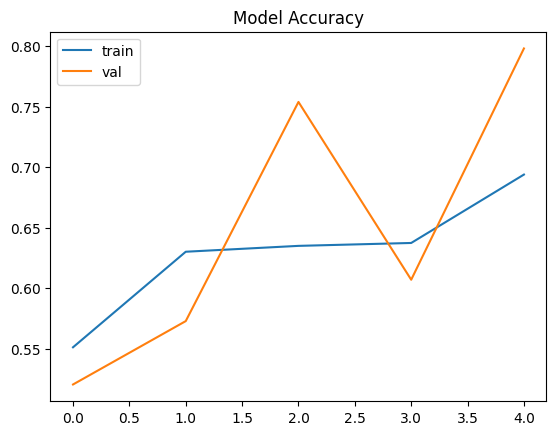

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title("Model Accuracy")
plt.show()

STEP 12 — Predict Your Own Review

In [20]:
def predict_review(text):
    text = tf.expand_dims(text, 0)
    text = vectorize_layer(text)
    prediction = model.predict(text)[0][0]

    if prediction > 0.5:
        print("Positive 😊")
    else:
        print("Negative 😞")

    print("Confidence:", prediction)

In [21]:
predict_review("This movie was amazing and full of emotions")
predict_review("Worst movie ever, I wasted my time")

1/1 [==============================] - 2s 2s/step
Positive 😊
Confidence: 0.7663464
1/1 [==============================] - 0s 99ms/step
Positive 😊
Confidence: 0.7645367


STEP 13 — Improve Model (Make it Stronger)

In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 128),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [23]:
# Recompile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [24]:
# trying again
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 [==============================] - 357s 544ms/step - loss: 0.6911 - accuracy: 0.5180 - val_loss: 0.6819 - val_accuracy: 0.5384
Epoch 2/5
625/625 [==============================] - 316s 505ms/step - loss: 0.6816 - accuracy: 0.5669 - val_loss: 0.6844 - val_accuracy: 0.5528
Epoch 3/5
625/625 [==============================] - 317s 508ms/step - loss: 0.6814 - accuracy: 0.5507 - val_loss: 0.6758 - val_accuracy: 0.5592
Epoch 4/5
625/625 [==============================] - 336s 538ms/step - loss: 0.6735 - accuracy: 0.5598 - val_loss: 0.6895 - val_accuracy: 0.5020
Epoch 5/5
625/625 [==============================] - 308s 493ms/step - loss: 0.6652 - accuracy: 0.5820 - val_loss: 0.6788 - val_accuracy: 0.5854


STEP 14 — Confusion Matrix

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
y_true = []
y_pred = []

for x, y in test_data:
    predictions = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

1/1 [==============================] - 3s 3s/step
Confusion Matrix:
 [[ 2532  9968]
 [  581 11919]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.20      0.32     12500
           1       0.54      0.95      0.69     12500

    accuracy                           0.58     25000
   macro avg       0.68      0.58      0.51     25000
weighted avg       0.68      0.58      0.51     25000

